## **Ejercicio 9. Análisis de contenido y sentimiento**

---

## **Carga de datos**

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 170)

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DIR_PROCESSED = RAIZ / "data" / "processed"

comentarios = pd.read_csv(DIR_PROCESSED / "comentarios_limpio.csv", keep_default_na=False)
videos = pd.read_csv(DIR_PROCESSED / "videos_limpio.csv", keep_default_na=False)
videos["vistas"] = pd.to_numeric(videos.vistas)

AZUL, NARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GRIS, TINTA, TINTA_SUAVE, REJILLA = "#9a9994", "#0b0b0b", "#52514e", "#d8d7d2"
plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlecolor": TINTA,
    "font.size": 9, "legend.frameon": False,
})

print(f"comentarios: {len(comentarios)}   videos: {len(videos)}")

comentarios: 406   videos: 293


---

## **9.1. Análisis de sentimiento**

Se usa **pysentimiento** (modelo `robertuito-sentiment-analysis`), entrenado en tuits en español,
para clasificar cada comentario en negativo, neutro o positivo. Se prefiere sobre un diccionario de
palabras porque entiende mejor el lenguaje informal, groserías y emojis, que aquí son parte
importante del sentimiento. Se aplica sobre el texto original (sin limpiar) porque mayúsculas,
puntuación y emojis también son señal para el modelo. El resultado ya estaba calculado desde el
ejercicio 7, así que aquí solo se reutiliza.

In [2]:
RUTA_SENTIMIENTO = DIR_PROCESSED / "comentarios_sentimiento.csv"

if RUTA_SENTIMIENTO.exists():
    sentimiento = pd.read_csv(RUTA_SENTIMIENTO)
    print(f"[cargado] {RUTA_SENTIMIENTO.name} -> {len(sentimiento)} filas")
else:
    from pysentimiento import create_analyzer

    analizador = create_analyzer(task="sentiment", lang="es")
    predicciones = analizador.predict(comentarios.texto_original.tolist())
    sentimiento = pd.DataFrame({
        "comment_id": comentarios.comment_id,
        "video_id": comentarios.video_id,
        "sentimiento": [r.output for r in predicciones],
        "prob_neg": [round(r.probas["NEG"], 4) for r in predicciones],
        "prob_neu": [round(r.probas["NEU"], 4) for r in predicciones],
        "prob_pos": [round(r.probas["POS"], 4) for r in predicciones],
    })
    sentimiento["puntaje_sentimiento"] = (sentimiento.prob_pos - sentimiento.prob_neg).round(4)
    sentimiento.to_csv(RUTA_SENTIMIENTO, index=False)
    print(f"[guardado] {RUTA_SENTIMIENTO.name} -> {len(sentimiento)} filas")

comentarios = comentarios.merge(
    sentimiento[["comment_id", "sentimiento", "puntaje_sentimiento", "prob_neg", "prob_neu", "prob_pos"]],
    on="comment_id",
)
comentarios = comentarios.merge(videos[["video_id", "channel_name", "title", "category"]],
                                 on="video_id", how="left", suffixes=("", "_video"))

print()
print("DISTRIBUCION GLOBAL DE SENTIMIENTO")
reparto = (comentarios.sentimiento.value_counts(normalize=True) * 100).round(1)
print(reparto.to_string())
print(f"puntaje medio (prob_pos - prob_neg): {comentarios.puntaje_sentimiento.mean():+.4f}")

[cargado] comentarios_sentimiento.csv -> 406 filas

DISTRIBUCION GLOBAL DE SENTIMIENTO
sentimiento
NEG    61.3
NEU    19.5
POS    19.2
puntaje medio (prob_pos - prob_neg): -0.3787


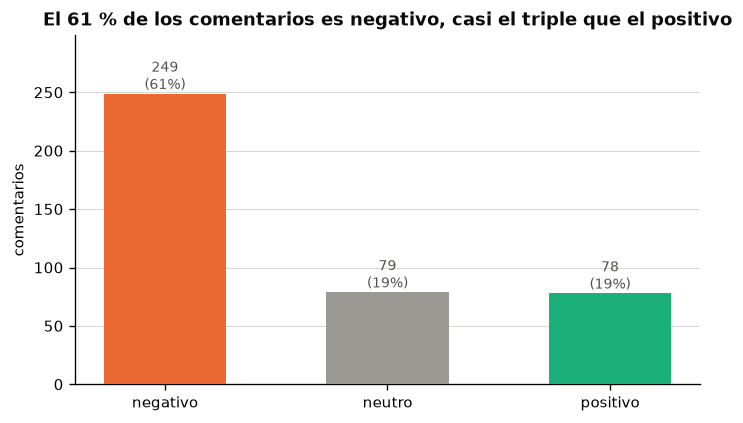

In [3]:
fig, ax = plt.subplots(figsize=(6, 3.6))
colores_sent = {"NEG": NARANJA, "NEU": GRIS, "POS": AQUA}
etiquetas_sent = {"NEG": "negativo", "NEU": "neutro", "POS": "positivo"}
orden = ["NEG", "NEU", "POS"]
valores = comentarios.sentimiento.value_counts()[orden]

ax.bar([etiquetas_sent[o] for o in orden], valores.values, color=[colores_sent[o] for o in orden],
       width=0.55, zorder=3)
for x, v in enumerate(valores.values):
    ax.text(x, v + 4, f"{v}\n({v / len(comentarios):.0%})", ha="center", fontsize=8.5, color=TINTA_SUAVE)
ax.grid(axis="y", color=REJILLA, linewidth=0.6)
ax.set_axisbelow(True)
ax.set_ylim(0, valores.max() * 1.2)
ax.set_ylabel("comentarios")
ax.set_title("El 61 % de los comentarios es negativo, casi el triple que el positivo")
for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)
plt.tight_layout()
plt.show()

De 406 comentarios: **61.3 % negativos, 19.5 % neutros, 19.2 % positivos**. El corpus es mayormente
de noticias y política (335 de 406 comentarios), lo cual explica el sesgo negativo: no es que los
usuarios de YouTube sean negativos en general, es que este tipo de contenido genera ese tono.

---

## **9.2. Comparación por video, canal y categoría**

In [4]:
print("POR CANAL (canales con 15 comentarios o más)")
por_canal = comentarios.groupby("channel_name").agg(
    comentarios=("comment_id", "count"),
    puntaje_medio=("puntaje_sentimiento", "mean"),
    pct_negativo=("sentimiento", lambda s: round((s == "NEG").mean() * 100, 1)),
    pct_positivo=("sentimiento", lambda s: round((s == "POS").mean() * 100, 1)),
)
por_canal = por_canal[por_canal.comentarios >= 15].sort_values("puntaje_medio").round(3)
por_canal

POR CANAL (canales con 15 comentarios o más)


,comentarios,puntaje_medio,pct_negativo,pct_positivo
channel_name,,,,
Quorum,256,-0.502,69.9,14.1
Noticias Telemundo,25,-0.473,64.0,8.0
Gobierno de la República de Guatemala,70,-0.221,50.0,24.3
Municipalidad de Guatemala,25,0.609,8.0,80.0


In [5]:
print("POR VIDEO (videos con 10 comentarios o más)")
por_video = comentarios.groupby(["video_id", "title"]).agg(
    comentarios=("comment_id", "count"),
    puntaje_medio=("puntaje_sentimiento", "mean"),
).round(3)
por_video = por_video[por_video.comentarios >= 10].sort_values("puntaje_medio")
por_video

POR VIDEO (videos con 10 comentarios o más)


,,comentarios,puntaje_medio
video_id,title,,
n8iP75gIpmw,Qué rico come tu diputado,161,-0.671
OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo,25,-0.473
PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,25,-0.422
j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,50,-0.342
yLZS3JiEBg8,Arroz con pollo a la MONOPOLIO,16,-0.236
06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,14,-0.177
6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,45,-0.109
ndAZjHqzzT8,Internet: escoger el menos malo,12,0.002
lj983NWyAQY,Plan 2032 Ciudad de Guatemala,25,0.609


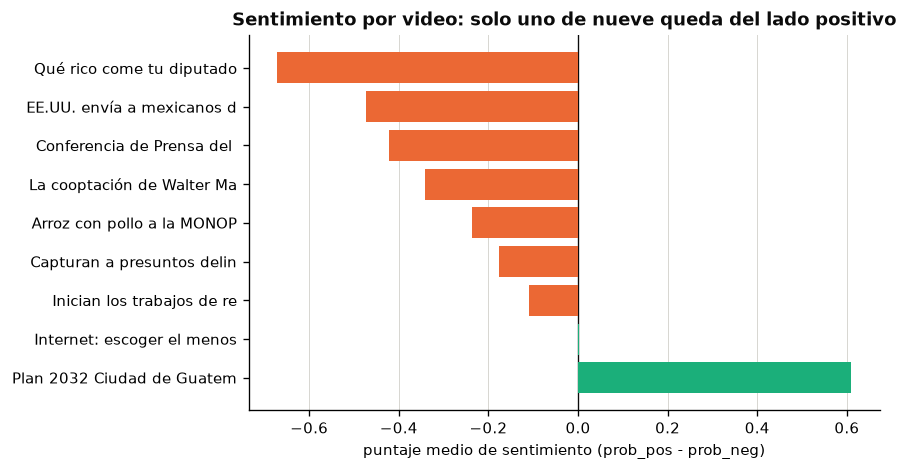

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4))
datos = por_video.reset_index()
colores_barra = [NARANJA if p < 0 else AQUA for p in datos.puntaje_medio]
etiquetas = [t[:26] for t in datos.title]

ax.barh(etiquetas, datos.puntaje_medio, color=colores_barra, zorder=3)
ax.axvline(0, color=TINTA, linewidth=0.8)
ax.grid(axis="x", color=REJILLA, linewidth=0.6)
ax.set_axisbelow(True)
ax.set_xlabel("puntaje medio de sentimiento (prob_pos - prob_neg)")
ax.set_title("Sentimiento por video: solo uno de nueve queda del lado positivo")
ax.invert_yaxis()
for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)
plt.tight_layout()
plt.show()

Por canal: **Municipalidad de Guatemala** es el único positivo (+0.609); **Quorum** es el más
negativo (-0.502) porque concentra la mayoría de los videos de denuncia. Por video: *Qué rico come
tu diputado* es el más negativo (-0.671, y aporta el 40 % de todos los comentarios); *Plan 2032* es
el único positivo (+0.609). No se compara por comunidad porque cada comunidad grande ya es,
básicamente, un solo video.

---

## **9.3. Hallazgos**

- **El tema manda, no el canal.** Los videos de denuncia (corrupción, gasto público) salen
  negativos; el video de obra pública sale positivo. Quorum sale mal en el promedio solo porque
  publica más denuncias, no porque su audiencia sea más negativa.
- **Un video jala todo el promedio.** *Qué rico come tu diputado* por sí solo aporta el 40 % de los
  comentarios, así que arrastra el resultado negativo global.
- **Negativo no siempre significa rechazo al video.** En algunos comentarios negativos aparecen
  emojis de aprobación (👏, 👍): la molestia es con el hecho denunciado, no con quien lo reporta.
- **Cuidado con muestras chicas.** Solo 4 canales y 9 videos tienen suficientes comentarios (15 y 10
  respectivamente) para comparar con confianza; el resto tiene muy pocos datos para sacar
  conclusiones firmes.